# # 종합 실습 가이드_ML / DL



- 실습 주제 : 의료 데이터를 활용해 환자의 1년 후 당뇨병 진행정도를 예측하는 모델 개발
- 실습 목표 : Test 데이터 기준 MAPE를 최소화하고, Feature 영향도 분석하기
- 실습 조건
  - 분석 데이타 : 아래 URL link 데이타를 사용
  - Target 변수 : target (당뇨 진행 정도: 값이 클수록 당뇨 진행정도가 높음). *Target 변수는 어떠한 데이타 변환도 하지 않음
  - 학습 조건 : 아래 Baseline Code 를 참고하여 (필수) 과정인 데이터 분할 및 Feature Engineering(데이터 변환 포함) 과정은 **아래 제시된 코드를 그대로 사용**하고, 학습 및 평가 단계에서 **모델의 종류와 하이퍼파라미터 값만 자율적으로 선택**
  - 데이타 건수 : 데이타 제거는 하지 않음 (전체/Train/Test 건수 그대로 유지), 중복 데이타가 있어도 제거하지 않음
- 실습 과제  

Q1) ML or DL 모델을 활용하여 Test 데이터 기준 MAPE를 최소화 하는 모델과 Hyperparameter 찾기. *조건 : Hyperparameter 자동 최적화 기법은 사용하지 않음

Q2) Tree 시각화에서 당뇨 진행정도가 가장 높은 집단과 가장 낮은 집단의 규칙(Rule)을 도출하기. *조건: Tree 깊이는 max_depth=3 로 하고 그외 Hyperparameter 값은 자율적으로 선택, Scaling 된 상태에서 Rule 생성

Q3) Random Forest 기준 특성 중요도(Feature Importance) 분석 결과 1~3위 Feature 찾기. *조건: Hyperparameter 값은 자율적으로 선택

- 실습 제출물
   - 종합실습_결과물_ML_DL_OOO.xlsx 에 실습 결과 작성 후 코드 (.ipynb)와 같이 제출   
   - 실습 결과는 제출 코드로 재현이 가능해야 함
   - 제출시 화일명은 본인 이름으로 2개 화일 제출 (엑셀, 코드)   
     예) **종합실습_결과물_ML_DL_홍길동.xlsx, 종합실습_결과물_ML_DL_홍길동.ipynb**
- [참고] 데이타 설명 : 당뇨병 환자의 건강 정보를 이용하여 1년 후 질병 진행 정도를 예측하는 표준화된 데이터셋

| 컬럼명    | 한글명           | 의미                            | 비고               |
| ------ | ------------- | ----------------------------- | ---------------- |
| age    | 나이            | 환자의 연령                        | 연속형              |
| sex    | 성별            | 환자의 성별                        | 연속형             |
| bmi    | 체질량지수(BMI)    | Body Mass Index               | 연속형              |
| bp     | 평균 혈압         | Average Blood Pressure        | 연속형              |
| s1     | 총 콜레스테롤       | Total Serum Cholesterol       | 연속형              |
| s2     | LDL           | 저밀도 지단백(LDL)                  | 연속형              |
| s3     | HDL           | 고밀도 지단백(HDL)                  | 연속형              |
| s4     | 총콜레스테롤/HDL 비율 | Total Cholesterol / HDL Ratio | 연속형              |
| s5     | 혈청 중성지방       | Serum Triglycerides           | 연속형              |
| s6     | 혈당            | Blood Glucose                 | 연속형              |
| target | 질병 진행 정도      | 1년 후 당뇨병 진행 정도를 나타내는 연속형 점수   | **종속변수(Target)** |


# Baseline Code
데이타 불러오기 **(필수)**

In [2]:
# ================================
# Random Seed 고정
# ================================

import tensorflow as tf

# Python, NumPy, TensorFlow Seed를 한 번에 설정
SEED = 42
tf.keras.utils.set_random_seed(SEED)


# ================================
# 데이타 불러오기
# ================================

import pandas as pd
from sklearn.datasets import load_diabetes

diabetes = load_diabetes()

df = pd.DataFrame(
    diabetes.data,
    columns=diabetes.feature_names
)

df["target"] = diabetes.target
print(df.head())

        age       sex       bmi        bp        s1        s2        s3  \
0  0.038076  0.050680  0.061696  0.021872 -0.044223 -0.034821 -0.043401   
1 -0.001882 -0.044642 -0.051474 -0.026328 -0.008449 -0.019163  0.074412   
2  0.085299  0.050680  0.044451 -0.005670 -0.045599 -0.034194 -0.032356   
3 -0.089063 -0.044642 -0.011595 -0.036656  0.012191  0.024991 -0.036038   
4  0.005383 -0.044642 -0.036385  0.021872  0.003935  0.015596  0.008142   

         s4        s5        s6  target  
0 -0.002592  0.019907 -0.017646   151.0  
1 -0.039493 -0.068332 -0.092204    75.0  
2 -0.002592  0.002861 -0.025930   141.0  
3  0.034309  0.022688 -0.009362   206.0  
4 -0.002592 -0.031988 -0.046641   135.0  


In [ ]:
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 442 entries, 0 to 441
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   age     442 non-null    float64
 1   sex     442 non-null    float64
 2   bmi     442 non-null    float64
 3   bp      442 non-null    float64
 4   s1      442 non-null    float64
 5   s2      442 non-null    float64
 6   s3      442 non-null    float64
 7   s4      442 non-null    float64
 8   s5      442 non-null    float64
 9   s6      442 non-null    float64
 10  target  442 non-null    float64
dtypes: float64(11)
memory usage: 38.1 KB


데이타 분할 및 Feature Engineering **(필수)**

In [2]:
# ================================
# 데이타 분할
# ================================

from sklearn.model_selection import train_test_split

# X, y 분리
X = df.drop('target', axis=1)
y = df['target']

# Train/Test 분리
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# ================================
# Misssing 처리
# ================================

# === 연속형 처리 ===

import numpy as np
import pandas as pd

# 연속형 변수 선택
num_cols = X_train.select_dtypes(include=[np.number]).columns

# Train 기준 중앙값 계산
median_values = X_train[num_cols].median()

# Train, Test 모두 Train 기준 중앙값으로 대체
X_train[num_cols] = X_train[num_cols].fillna(median_values)
X_test[num_cols] = X_test[num_cols].fillna(median_values)


# ================================
# Scaling 처리
# ================================

# Min-Max Scaling

from sklearn.preprocessing import MinMaxScaler

# 연속형 변수 추출
num_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()

# Min-Max Scaling
scaler = MinMaxScaler()

# Train
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])

 # Test
X_test[num_cols] = scaler.transform(X_test[num_cols])

학습 및 평가

## Decision Tree

In [3]:
# ================================
# 의사결정나무
# ================================
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_percentage_error

# 모델 정의
model = DecisionTreeRegressor(
    max_depth=3,       # Tree 깊이
    random_state=42
)

# 모델 학습
model.fit(X_train, y_train)

# 예측값 생성
train_pred = model.predict(X_train)
test_pred = model.predict(X_test)

# 모델 평가
print(f"\n=== DecisionTreeRegressor ===")
print(f"Train MAPE: {mean_absolute_percentage_error(y_train, train_pred) * 100:.3f}")
print(f"Test  MAPE: {mean_absolute_percentage_error(y_test, test_pred) * 100:.3f}")


=== DecisionTreeRegressor ===
Train MAPE: 39.392
Test  MAPE: 42.511


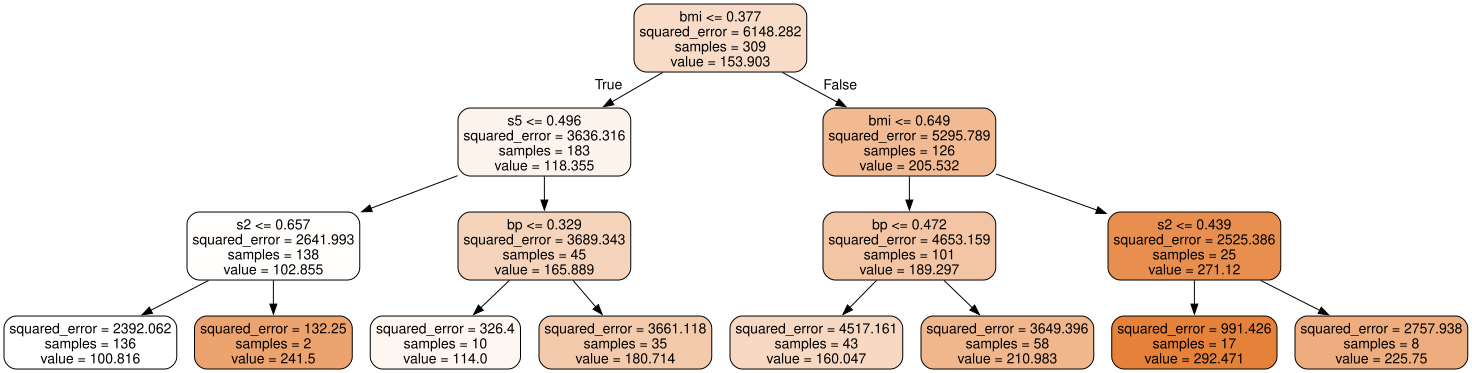

In [9]:
from sklearn.tree import export_graphviz
import graphviz

dot_data = export_graphviz(
    model,
    feature_names=X_train.columns,
    filled=True,
    rounded=True,
    proportion=False   # 비율 기준 출력
)
graphviz.Source(dot_data)

## Random Forest

In [61]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import accuracy_score

# 모델 정의
model = RandomForestRegressor(
    n_estimators=300,       # 트리 개수
    max_depth=5,            # 각 트리의 최대 깊이
    random_state=42
)

# 모델 학습
model.fit(X_train, y_train)

# 예측값 생성
train_pred = model.predict(X_train)
test_pred = model.predict(X_test)

# 모델 평가
print(f"Train MAPE: {mean_absolute_percentage_error(y_train, train_pred) * 100:.3f}%")
print(f"Test  MAPE: {mean_absolute_percentage_error(y_test, test_pred) * 100:.3f}%")

Train MAPE: 29.702%
Test  MAPE: 37.312%


  Feature  Importance
2     bmi    0.538198
8      s5    0.152697
3      bp    0.093519
9      s6    0.069385
6      s3    0.059635
0     age    0.024353
7      s4    0.019312
4      s1    0.018873
5      s2    0.013575
1     sex    0.010452


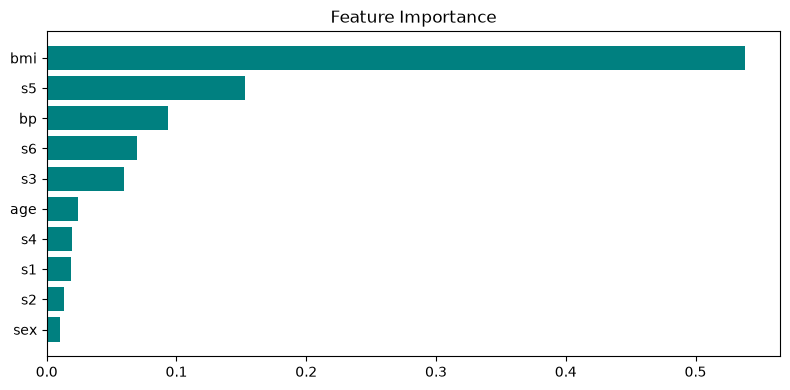

In [14]:
import matplotlib.pyplot as plt

# Feature Importance
importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': model.feature_importances_
}).sort_values('Importance', ascending=False)

print(importance)

# 시각화
plt.figure(figsize=(8, 4))
plt.barh(importance["Feature"], importance["Importance"], color="teal")
plt.gca().invert_yaxis()
plt.title("Feature Importance")
plt.tight_layout()
plt.show()

## XGBoost

In [37]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_percentage_error

# 모델 정의
model = XGBRegressor(
    n_estimators=64,
    max_depth=4,
    learning_rate=0.1,
    random_state=42,
)

# 모델 학습
model.fit(X_train, y_train)

# 예측값 생성
train_pred = model.predict(X_train)
test_pred = model.predict(X_test)

# 모델 평가
print(f"Train MAPE: {mean_absolute_percentage_error(y_train, train_pred) * 100:.3f}%")
print(f"Test  MAPE: {mean_absolute_percentage_error(y_test, test_pred) * 100:.3f}%")

Train MAPE: 18.549%
Test  MAPE: 39.107%


## LightGBM

In [47]:
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_absolute_percentage_error

# 모델 정의
model = LGBMRegressor(
    n_estimators=32,
    max_depth=3,
    learning_rate=0.1,
    random_state=42,
    verbosity=-1      # 로그 출력 안 함
)

# 모델 학습
model.fit(X_train, y_train)

# 예측값 생성
train_pred = model.predict(X_train)
test_pred = model.predict(X_test)

# 모델 평가
print(f"Train MAPE: {mean_absolute_percentage_error(y_train, train_pred) * 100:.3f}%")
print(f"Test  MAPE: {mean_absolute_percentage_error(y_test, test_pred) * 100:.3f}%")

Train MAPE: 34.067%
Test  MAPE: 37.005%


## MLP

In [ ]:
import time
from sklearn.metrics import mean_absolute_percentage_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam
import tensorflow as tf

start_time = time.time()

# Random Seed 고정
SEED = 42
tf.keras.utils.set_random_seed(SEED)

# 모델 정의, *Sequential: Layer를 쌓아 모델을 구성하는 방식
model = Sequential([
    Dense(64, activation="relu", input_shape=(X_train.shape[1],)),           # 은닉층 1번째, 64개 노드(뉴런), X_train.shape[1]: 피처갯수
    Dense(32, activation="relu"),                                            # 은닉층 2번째, 32개 노드(뉴런)
    Dense(16, activation="relu"),                                            # 은닉층 3번째, 16개 노드(뉴런)
    Dense(8, activation="relu"),                                             # 은닉층 4번째, 8개 노드(뉴런)
    Dense(1)                                                                 # 출력층, 예측값 1개
])

# 모델 컴파일
model.compile(
    optimizer=Adam(learning_rate=0.1),   # Optimizer: Adam, 학습률 : 0.1
    loss="mse"                           # 손실함수는 일반적으로 '0' 근처에서 안정적인 mse 를 사용
)

# EarlyStopping 정의
early_stop = EarlyStopping(
    monitor="val_loss",           # 학습 데이터가 아니라 검증 데이터 기준으로 멈춤
    patience=10,                   # 최저점 이후 5번 더 참았다가 멈춤
    restore_best_weights=True     # 가장 val_loss가 좋았던 시점의 가중치로 되돌림
)

# 모델 학습
model.fit(
    X_train,
    y_train,
    validation_split=0.2,     # validation set 비율
    epochs=100,                # 에포크수
    batch_size=32,            # 배치크기
    callbacks=[early_stop],   # EarlyStopping 조건 실행
    verbose=1                 # 학습 과정 출력
)

# 예측값 생성
train_pred = model.predict(X_train).ravel()
test_pred  = model.predict(X_test).ravel()

end_time = time.time()

# 모델 평가
print("\n=== MLP ===")
print(f"Train MAPE : {mean_absolute_percentage_error(y_train, train_pred) * 100:.3f}%")
print(f"Test  MAPE : {mean_absolute_percentage_error(y_test, test_pred) * 100:.3f}%")

# 소요 시간
print(f"Execution Time : {end_time - start_time:.2f} sec")

Epoch 1/100


/opt/homebrew/lib/python3.11/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 17999.3203 - val_loss: 7604.9126
Epoch 2/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 7387.5977 - val_loss: 5788.4165
Epoch 3/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5982.9502 - val_loss: 5006.2212
Epoch 4/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5332.7856 - val_loss: 4248.0728
Epoch 5/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4539.2212 - val_loss: 3846.8831
Epoch 6/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 3803.1609 - val_loss: 3787.7942
Epoch 7/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 3392.0459 - val_loss: 3845.0449
Epoch 8/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 3239.1162 - val_loss: 3882.5435
Epoch 9/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 3215.3643 - val_loss: 3882.4485
Epoch 10/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 3260.1565 - val_loss: 3877.9561
Epoch 11/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 3329.5981 - val_loss: 3877.8647
Epoch 12/100
8/8 ━━━━━━━━━━━━━